# Copy-Transformer для sim8

Обучение минимального трансформера, который копирует 4-символьную строку
через разделитель: `A B A D → A B A D | A B A D`.

**Особенности этой версии:**
- Без LayerNorm (упрощение для реализации на sim8).
- Hardmax вместо softmax в attention (нет `exp(x)` в sim8).
- Float16 веса (целевой формат sim8).
- Entropy penalty для заострения attention pattern.

## Структура
1. Данные
2. Модель
3. Loss с entropy penalty
4. Обучение
5. Проверки: softmax accuracy, hardmax accuracy, float16 accuracy
6. Анализ attention pattern
7. Golden reference для верификации sim8
8. Экспорт весов в bin-файлы по тензорам

## 0. Импорты и константы

In [14]:
import math
import os
from itertools import product

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Словарь
VOCAB = ['A', 'B', 'C', 'D', '|']
VOCAB_SIZE = len(VOCAB)
char_to_id = {ch: i for i, ch in enumerate(VOCAB)}
id_to_char = {i: ch for i, ch in enumerate(VOCAB)}

# Гиперпараметры модели
D_MODEL = 8
D_FF = 16
MAX_LEN = 9       # 4 + | + 4
TRAIN_LEN = 8     # длина после среза inputs/targets

print(f"Vocab: {VOCAB} (size {VOCAB_SIZE})")
print(f"Model: d_model={D_MODEL}, d_ff={D_FF}, max_len={MAX_LEN}")

Vocab: ['A', 'B', 'C', 'D', '|'] (size 5)
Model: d_model=8, d_ff=16, max_len=9


## 1. Данные

Полный датасет: все $4^4 = 256$ строк длины 4 над $\{A,B,C,D\}$.
Для каждой строки $x$ строится полный пример $x \,|\, x$ длины 9.

Loss считается только на позициях 3–7:
- pos 3: модель учится ставить `|`
- pos 4–7: модель учится копировать

In [15]:
def make_example(input_str):
    full = input_str + '|' + input_str
    return [char_to_id[ch] for ch in full]

def build_dataset():
    examples = []
    for combo in product('ABCD', repeat=4):
        examples.append(make_example(''.join(combo)))
    return torch.tensor(examples, dtype=torch.long)

dataset = build_dataset()                # [256, 9]
inputs  = dataset[:, :-1]                # [256, 8]
targets = dataset[:,  1:]                # [256, 8]

loss_mask = torch.zeros(TRAIN_LEN, dtype=torch.bool)
loss_mask[3:8] = True                    # позиции 3..7 учитываются

print(f"Dataset: {dataset.shape}")
print(f"Inputs:  {inputs.shape}")
print(f"Targets: {targets.shape}")
print(f"Loss mask: {loss_mask.tolist()}")

Dataset: torch.Size([256, 9])
Inputs:  torch.Size([256, 8])
Targets: torch.Size([256, 8])
Loss mask: [False, False, False, True, True, True, True, True]


## 2. Модель

Decoder-only трансформер с одним блоком, без LayerNorm.
Attention сохраняет последний pattern в `self.last_attn` — нужно для entropy penalty.

In [16]:
class Embedding(nn.Module):
    def __init__(self, vocab_size, max_len, d_model):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb   = nn.Embedding(max_len,   d_model)

    def forward(self, x):
        B, T = x.shape
        positions = torch.arange(T, device=x.device)
        return self.token_emb(x) + self.pos_emb(positions)


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.last_attn = None   # для entropy penalty в loss

    def forward(self, x):
        B, T, D = x.shape
        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)

        scores = q @ k.transpose(-2, -1) / math.sqrt(D)
        mask = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool))
        scores = scores.masked_fill(~mask, float('-inf'))

        attn = torch.softmax(scores, dim=-1)
        self.last_attn = attn
        out = attn @ v
        out = self.W_o(out)
        return out


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(torch.relu(self.linear1(x)))


class TransformerBlock(nn.Module):
    """Без LayerNorm. Только attention + residual + FFN + residual."""
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.attn = CausalSelfAttention(d_model)
        self.ffn  = FeedForward(d_model, d_ff)

    def forward(self, x):
        x = x + self.attn(x)
        x = x + self.ffn(x)
        return x


class TransformerLM(nn.Module):
    def __init__(self, vocab_size, max_len, d_model, d_ff):
        super().__init__()
        self.embedding = Embedding(vocab_size, max_len, d_model)
        self.block     = TransformerBlock(d_model, d_ff)
        self.head      = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.block(x)
        return self.head(x)

## 3. Loss

$$L = \text{CE}(\text{logits}, \text{targets}) + \lambda \cdot H(\text{attn})$$

Энтропия attention pattern минимизируется → attention становится близким к one-hot,
и hardmax-инференс начинает работать.

In [17]:
def attention_entropy(attn, loss_mask, eps=1e-9):
    ent = -(attn * torch.log(attn + eps)).sum(dim=-1)   # [B, T]
    return ent[:, loss_mask].mean()


def compute_loss(model, logits, targets, loss_mask, entropy_weight=0.5):
    B, T, V = logits.shape
    loss_per_token = nn.functional.cross_entropy(
        logits.reshape(B * T, V),
        targets.reshape(B * T),
        reduction='none',
    ).reshape(B, T)
    mask = loss_mask.unsqueeze(0).expand(B, T)
    ce = loss_per_token[mask].mean()

    ent = attention_entropy(model.block.attn.last_attn, loss_mask)
    total = ce + entropy_weight * ent
    return total, ce.item(), ent.item()

## 4. Обучение

In [18]:
torch.manual_seed(42)
model = TransformerLM(VOCAB_SIZE, MAX_LEN, D_MODEL, D_FF)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# === Фаза 1: обучение без entropy penalty ===
print("=== Phase 1: softmax learning (entropy_weight=0) ===")
for epoch in range(5000):
    logits = model(inputs)
    loss, ce, ent = compute_loss(model, logits, targets, loss_mask, entropy_weight=0.0)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | ce = {ce:.4f} | ent = {ent:.4f}")

# Промежуточная проверка
with torch.no_grad():
    preds = model(inputs).argmax(dim=-1)
    correct = ((preds == targets) & loss_mask.unsqueeze(0)).sum().item()
    total = loss_mask.sum().item() * inputs.shape[0]
    print(f"\nPhase 1 softmax accuracy: {100*correct/total:.1f}%")

# === Фаза 2: заострение attention ===
print("\n=== Phase 2: attention sharpening (entropy_weight=2.0) ===")
for epoch in range(3000):
    logits = model(inputs)
    loss, ce, ent = compute_loss(model, logits, targets, loss_mask, entropy_weight=2.0)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 300 == 0:
        print(f"Epoch {epoch:5d} | ce = {ce:.4f} | ent = {ent:.4f}")

print("\nDone.")

=== Phase 1: softmax learning (entropy_weight=0) ===
Epoch     0 | ce = 2.0525 | ent = 1.6467
Epoch   500 | ce = 0.0033 | ent = 0.6791
Epoch  1000 | ce = 0.0005 | ent = 0.6145
Epoch  1500 | ce = 0.0002 | ent = 0.5877
Epoch  2000 | ce = 0.0001 | ent = 0.5706
Epoch  2500 | ce = 0.0001 | ent = 0.5575
Epoch  3000 | ce = 0.0000 | ent = 0.5468
Epoch  3500 | ce = 0.0000 | ent = 0.5377
Epoch  4000 | ce = 0.0000 | ent = 0.5297
Epoch  4500 | ce = 0.0000 | ent = 0.5225

Phase 1 softmax accuracy: 100.0%

=== Phase 2: attention sharpening (entropy_weight=2.0) ===
Epoch     0 | ce = 0.0000 | ent = 0.5159
Epoch   300 | ce = 0.0000 | ent = 0.0007
Epoch   600 | ce = 0.0000 | ent = 0.0003
Epoch   900 | ce = 0.0000 | ent = 0.0002
Epoch  1200 | ce = 0.0000 | ent = 0.0001
Epoch  1500 | ce = 0.0000 | ent = 0.0001
Epoch  1800 | ce = 0.0000 | ent = 0.0001
Epoch  2100 | ce = 0.0000 | ent = 0.0000
Epoch  2400 | ce = 0.0000 | ent = 0.0000
Epoch  2700 | ce = 0.0000 | ent = 0.0000

Done.


## 5. Проверки точности

Три варианта:
1. **Softmax accuracy** (стандартный inference).
2. **Hardmax accuracy** (argmax вместо softmax в attention) — это то, что будет делать sim8.
3. **Float16 accuracy** (модель сконвертирована в half).

Цель — все три на позициях 3–7 показывают 100%.

In [19]:
@torch.no_grad()
def hardmax_forward(model, x):
    """Forward pass с заменой softmax на argmax-one-hot в attention."""
    model.eval()
    h = model.embedding(x)
    q = model.block.attn.W_q(h)
    k = model.block.attn.W_k(h)
    v = model.block.attn.W_v(h)
    B, T, D = q.shape
    scores = q @ k.transpose(-2, -1) / math.sqrt(D)
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    scores = scores.masked_fill(~mask, float('-inf'))

    argmax_idx = scores.argmax(dim=-1, keepdim=True)
    hardmax = torch.zeros_like(scores)
    hardmax.scatter_(-1, argmax_idx, 1.0)

    av = hardmax @ v
    attn_out = model.block.attn.W_o(av)
    h = h + attn_out
    h = h + model.block.ffn(h)
    return model.head(h)


def accuracy_by_position(predictions, targets, loss_mask, label):
    print(f"--- {label} ---")
    for pos in range(TRAIN_LEN):
        correct = (predictions[:, pos] == targets[:, pos]).sum().item()
        total = predictions.shape[0]
        marker = " ← важна" if loss_mask[pos] else ""
        print(f"  pos {pos}: {correct}/{total} = {100*correct/total:5.1f}%{marker}")
    print()


# 1. Softmax
with torch.no_grad():
    model.eval()
    preds_sm = model(inputs).argmax(dim=-1)
accuracy_by_position(preds_sm, targets, loss_mask, "Softmax (training-time) accuracy")

# 2. Hardmax
preds_hm = hardmax_forward(model, inputs).argmax(dim=-1)
accuracy_by_position(preds_hm, targets, loss_mask, "Hardmax accuracy")

# 3. Float16
with torch.no_grad():
    model_fp16 = TransformerLM(VOCAB_SIZE, MAX_LEN, D_MODEL, D_FF).half()
    model_fp16.load_state_dict({k: v.half() for k, v in model.state_dict().items()})
    model_fp16.eval()
    preds_fp16 = model_fp16(inputs).argmax(dim=-1)
accuracy_by_position(preds_fp16, targets, loss_mask, "Float16 (softmax) accuracy")

--- Softmax (training-time) accuracy ---
  pos 0: 64/256 =  25.0%
  pos 1: 64/256 =  25.0%
  pos 2: 64/256 =  25.0%
  pos 3: 256/256 = 100.0% ← важна
  pos 4: 256/256 = 100.0% ← важна
  pos 5: 256/256 = 100.0% ← важна
  pos 6: 256/256 = 100.0% ← важна
  pos 7: 256/256 = 100.0% ← важна

--- Hardmax accuracy ---
  pos 0: 64/256 =  25.0%
  pos 1: 64/256 =  25.0%
  pos 2: 64/256 =  25.0%
  pos 3: 256/256 = 100.0% ← важна
  pos 4: 256/256 = 100.0% ← важна
  pos 5: 256/256 = 100.0% ← важна
  pos 6: 256/256 = 100.0% ← важна
  pos 7: 256/256 = 100.0% ← важна

--- Float16 (softmax) accuracy ---
  pos 0: 64/256 =  25.0%
  pos 1: 64/256 =  25.0%
  pos 2: 64/256 =  25.0%
  pos 3: 256/256 = 100.0% ← важна
  pos 4: 256/256 = 100.0% ← важна
  pos 5: 256/256 = 100.0% ← важна
  pos 6: 256/256 = 100.0% ← важна
  pos 7: 256/256 = 100.0% ← важна



## 6. Анализ attention pattern

Визуализация выученного механизма копирования: для позиций 4–7 attention должен
указывать на позиции 0–3 соответственно.

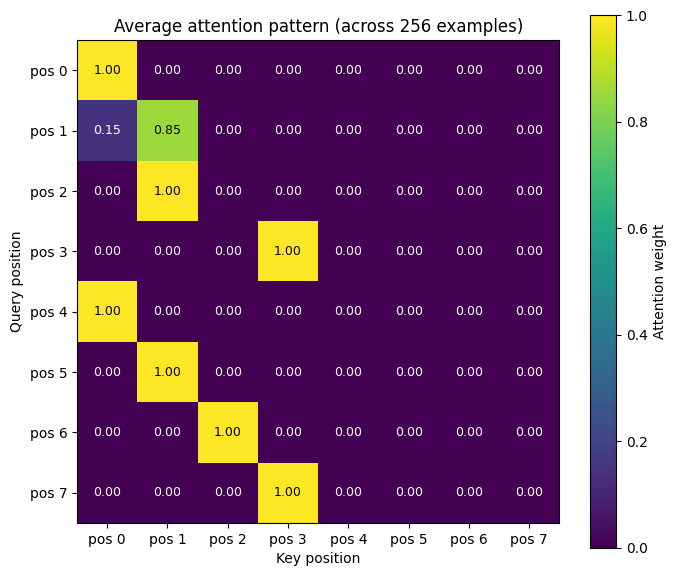

In [20]:
@torch.no_grad()
def get_attention_for(model, example_input):
    model.eval()
    model(example_input)   # запускаем forward — attention сохранится в last_attn
    return model.block.attn.last_attn[0]


@torch.no_grad()
def average_attention(model, all_inputs):
    model.eval()
    model(all_inputs)
    return model.block.attn.last_attn.mean(dim=0).numpy()


avg_pattern = average_attention(model, inputs)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(avg_pattern, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(TRAIN_LEN)); ax.set_yticks(range(TRAIN_LEN))
ax.set_xticklabels([f"pos {i}" for i in range(TRAIN_LEN)])
ax.set_yticklabels([f"pos {i}" for i in range(TRAIN_LEN)])
ax.set_xlabel("Key position"); ax.set_ylabel("Query position")
ax.set_title("Average attention pattern (across 256 examples)")
for i in range(TRAIN_LEN):
    for j in range(TRAIN_LEN):
        v = avg_pattern[i, j]
        color = "white" if v < 0.5 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=9)
plt.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("attention_pattern.png", dpi=150)
plt.show()

## 7. Golden reference для sim8

Пошаговый hardmax-forward для одного примера длины 9 (`A B A D | A B A D`).
Каждый промежуточный тензор сохраняется в `trace_detailed.npz` — это эталон
для побайтной сверки с дампами памяти sim8.

In [21]:
@torch.no_grad()
def golden_forward_hardmax(model, full_sequence):
    """Forward pass с hardmax вместо softmax. Без LayerNorm.
    full_sequence: [1, T] — полная последовательность (любой длины ≤ MAX_LEN).
    """
    model.eval()
    trace = {}
    T = full_sequence.shape[1]

    trace["00_tokens"] = full_sequence[0].clone()

    x = model.embedding(full_sequence)
    trace["01_embedding"] = x[0].clone()

    q = model.block.attn.W_q(x)
    k = model.block.attn.W_k(x)
    v = model.block.attn.W_v(x)
    trace["02_q"] = q[0].clone()
    trace["02_k"] = k[0].clone()
    trace["02_v"] = v[0].clone()

    scores = q @ k.transpose(-2, -1) / math.sqrt(D_MODEL)
    mask = torch.tril(torch.ones(T, T, dtype=torch.bool))
    scores = scores.masked_fill(~mask, float('-inf'))
    trace["03_scores"] = scores[0].clone()

    argmax_idx = scores.argmax(dim=-1, keepdim=True)
    hardmax = torch.zeros_like(scores)
    hardmax.scatter_(-1, argmax_idx, 1.0)
    trace["04_attn_argmax"] = argmax_idx[0, :, 0].clone()

    av = hardmax @ v
    trace["05_av"] = av[0].clone()

    attn_out = model.block.attn.W_o(av)
    trace["06_attn_out"] = attn_out[0].clone()

    x_after_attn = x + attn_out
    trace["07_after_attn_residual"] = x_after_attn[0].clone()

    h = torch.relu(model.block.ffn.linear1(x_after_attn))
    trace["08_ffn_hidden"] = h[0].clone()
    ffn_out = model.block.ffn.linear2(h)
    trace["09_ffn_out"] = ffn_out[0].clone()

    x_final = x_after_attn + ffn_out
    trace["10_after_ffn_residual"] = x_final[0].clone()

    logits = model.head(x_final)
    trace["11_logits"] = logits[0].clone()
    trace["12_predictions"] = logits.argmax(dim=-1)[0].clone()

    return trace


# Эталон для тестовой последовательности 'A B A D | A B A D'
test_seq = torch.tensor([[0, 1, 0, 3, 4, 0, 1, 0, 3]])
test_chars = [id_to_char[i.item()] for i in test_seq[0]]
print(f"Test input: {' '.join(test_chars)}")

trace = golden_forward_hardmax(model, test_seq)
predicted = [id_to_char[i.item()] for i in trace["12_predictions"]]
print(f"Predictions: {' '.join(predicted)}")
print(f"Predictions at positions 3..7 (the ones we care about): {predicted[3:8]}")

np.savez(
    "trace_detailed.npz",
    **{name: t.numpy() for name, t in trace.items()},
)
print("\nSaved trace_detailed.npz")
for name, t in trace.items():
    print(f"  {name:35s} {tuple(t.shape)}")

Test input: A B A D | A B A D
Predictions: A B B | A B A D |
Predictions at positions 3..7 (the ones we care about): ['|', 'A', 'B', 'A', 'D']

Saved trace_detailed.npz
  00_tokens                           (9,)
  01_embedding                        (9, 8)
  02_q                                (9, 8)
  02_k                                (9, 8)
  02_v                                (9, 8)
  03_scores                           (9, 9)
  04_attn_argmax                      (9,)
  05_av                               (9, 8)
  06_attn_out                         (9, 8)
  07_after_attn_residual              (9, 8)
  08_ffn_hidden                       (9, 16)
  09_ffn_out                          (9, 8)
  10_after_ffn_residual               (9, 8)
  11_logits                           (9, 5)
  12_predictions                      (9,)


## 8. Экспорт весов

Каждый тензор сохраняется в отдельный `.bin` (float16, little-endian) — формат,
который sim8-ассемблер подключает через `@include`. Тензоры LayerNorm отсутствуют.

In [25]:
# Порядок и размер тензоров — модель без LayerNorm
TENSORS = [
    "embedding.token_emb.weight",
    "embedding.pos_emb.weight",
    "block.attn.W_q.weight",
    "block.attn.W_k.weight",
    "block.attn.W_v.weight",
    "block.attn.W_o.weight",
    "block.ffn.linear1.weight",
    "block.ffn.linear1.bias",
    "block.ffn.linear2.weight",
    "block.ffn.linear2.bias",
    "head.weight",
    "head.bias",
]

# Короткие имена для файлов
SHORT_NAME = {
    "embedding.token_emb.weight":   "token_emb",
    "embedding.pos_emb.weight":     "pos_emb",
    "block.attn.W_q.weight":        "W_q",
    "block.attn.W_k.weight":        "W_k",
    "block.attn.W_v.weight":        "W_v",
    "block.attn.W_o.weight":        "W_o",
    "block.ffn.linear1.weight":     "W1",
    "block.ffn.linear1.bias":       "b1",
    "block.ffn.linear2.weight":     "W2",
    "block.ffn.linear2.bias":       "b2",
    "head.weight":                  "head_W",
    "head.bias":                    "head_b",
}

os.makedirs("weights_split", exist_ok=True)

state = model.state_dict()
total = 0
print(f"{'name':28s} {'short':10s} {'shape':>14s} {'bytes':>6s}")
print("-" * 65)
for full_name in TENSORS:
    t = state[full_name].detach().cpu().to(torch.float16).numpy()
    flat = t.flatten()
    short = SHORT_NAME[full_name]
    path = f"weights_split/{short}.bin"
    flat.tofile(path)
    n_bytes = flat.nbytes
    total += n_bytes
    print(f"{full_name:28s} {short:10s} {str(tuple(t.shape)):>14s} {n_bytes:6d}")
print("-" * 65)
print(f"{'TOTAL':>55s} {total:6d}")

name                         short               shape  bytes
-----------------------------------------------------------------
embedding.token_emb.weight   token_emb          (5, 8)     80
embedding.pos_emb.weight     pos_emb            (9, 8)    144
block.attn.W_q.weight        W_q                (8, 8)    128
block.attn.W_k.weight        W_k                (8, 8)    128
block.attn.W_v.weight        W_v                (8, 8)    128
block.attn.W_o.weight        W_o                (8, 8)    128
block.ffn.linear1.weight     W1                (16, 8)    256
block.ffn.linear1.bias       b1                  (16,)     32
block.ffn.linear2.weight     W2                (8, 16)    256
block.ffn.linear2.bias       b2                   (8,)     16
head.weight                  head_W             (5, 8)     80
head.bias                    head_b               (5,)     10
-----------------------------------------------------------------
                                                  TOTAL   1386

## 9. Утилита для сверки дампов памяти sim8 с golden reference

In [26]:
def parse_hex_dump(dump_text):
    """Парсит дамп памяти sim8 в массив байт.
    Формат строк: 'ADDR HH HH HH ...' или просто 'HH HH HH ...'.
    """
    bytes_list = []
    for line in dump_text.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        tokens = line.split()
        # Если первый токен — 4-значный hex-адрес, пропускаем его
        if len(tokens[0]) == 4 and all(c in '0123456789ABCDEFabcdef' for c in tokens[0]):
            tokens = tokens[1:]
        bytes_list.extend(int(t, 16) for t in tokens)
    return np.array(bytes_list, dtype=np.uint8)


def compare_with_golden(dump_text, golden_tensor, label=""):
    """Сравнивает дамп sim8 (как float16) с golden-тензором (любой dtype)."""
    raw = parse_hex_dump(dump_text)
    sim8 = np.frombuffer(raw.tobytes(), dtype=np.float16).reshape(golden_tensor.shape)
    golden = golden_tensor.astype(np.float32) if hasattr(golden_tensor, 'astype') else golden_tensor.numpy().astype(np.float32)
    diff = np.abs(sim8.astype(np.float32) - golden)
    print(f"--- {label} ---")
    print(f"Max abs diff: {diff.max():.6f}")
    print(f"Mean abs diff: {diff.mean():.6f}")
    if diff.max() > 0.01:
        print("⚠ Расхождение значительное — стоит исследовать.")
        for i in range(min(golden.shape[0], 10)):
            if diff[i].max() > 0.01:
                print(f"  row {i}: golden={golden[i]}, sim8={sim8[i]}")
    else:
        print("✓ Расхождение в пределах float16 ULP.")
    return sim8


# Пример использования (когда будет дамп из sim8):
# dump = """
# 1100 80 23 A0 2F 39 40 CE BA 30 AC 69 B4 9D 3E 74 BD
# ... (всего 144 байта = 9 строк × 16) ...
# """
# compare_with_golden(dump, trace["01_embedding"], "embedding")

In [27]:
import os
import time
for f in sorted(os.listdir("weights_split")):
    path = f"weights_split/{f}"
    mtime = time.ctime(os.path.getmtime(path))
    size = os.path.getsize(path)
    print(f"{f:14s} {size:6d} bytes  {mtime}")

W1.bin            256 bytes  Wed May 20 11:14:15 2026
W2.bin            256 bytes  Wed May 20 11:14:15 2026
W_k.bin           128 bytes  Wed May 20 11:14:15 2026
W_o.bin           128 bytes  Wed May 20 11:14:15 2026
W_q.bin           128 bytes  Wed May 20 11:14:15 2026
W_v.bin           128 bytes  Wed May 20 11:14:15 2026
b1.bin             32 bytes  Wed May 20 11:14:15 2026
b2.bin             16 bytes  Wed May 20 11:14:15 2026
head_W.bin         80 bytes  Wed May 20 11:14:15 2026
head_b.bin         10 bytes  Wed May 20 11:14:15 2026
pos_emb.bin       144 bytes  Wed May 20 11:14:15 2026
token_emb.bin      80 bytes  Wed May 20 11:14:15 2026


In [28]:
trace = np.load("trace_detailed.npz")
golden_q00 = trace["02_q"][0, 0]
golden_q00_fp16 = np.float16(golden_q00)
print(f"Golden Q[0,0] = {golden_q00:.6f}")
print(f"As fp16:        {golden_q00_fp16}")
print(f"Bytes (LE):     {golden_q00_fp16.tobytes().hex().upper()}")

Golden Q[0,0] = -1.567171
As fp16:        -1.5673828125
Bytes (LE):     45BE


In [31]:
trace = np.load("trace_detailed.npz")
for name, page in [("Q", 18), ("K", 19), ("V", 20)]:
    print(f"--- {name} (page {page}) ---")
    golden_row0 = trace[f"02_{name.lower()}"][0].astype(np.float16)
    print(f"  Golden row0 bytes: {golden_row0.tobytes().hex().upper()}")

--- Q (page 18) ---
  Golden row0 bytes: 45BEF1BE38C1FAC2793FEA437E2C6A42
--- K (page 19) ---
  Golden row0 bytes: 17401940D8BDBE429CBE1AB59EBA2D41
--- V (page 20) ---
  Golden row0 bytes: 304456BFE94027BCBDBCEDAECF3FC141
